# Hotel Booking Demand — EDA
Following `docs/eda_checklist.md`.

Source: Kaggle (`jessemostipak/hotel-booking-demand`), originally Antonio, Almeida & Nunes (2019), *Data in Brief*. Single file, booking-level rows for a City Hotel and a Resort Hotel in Portugal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_DIR = "../../data/raw/hospitality/hotel_booking_demand"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
df = pd.read_csv(f"{DATA_DIR}/hotel_bookings.csv")
print("shape:", df.shape)
df.head()

shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

## 2. Missing Values

In [4]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

company                           94.31
agent                             13.69
country                            0.41
hotel                              0.00
arrival_date_month                 0.00
arrival_date_week_number           0.00
lead_time                          0.00
is_canceled                        0.00
stays_in_weekend_nights            0.00
stays_in_week_nights               0.00
children                           0.00
adults                             0.00
babies                             0.00
meal                               0.00
arrival_date_day_of_month          0.00
arrival_date_year                  0.00
distribution_channel               0.00
market_segment                     0.00
previous_bookings_not_canceled     0.00
is_repeated_guest                  0.00
reserved_room_type                 0.00
assigned_room_type                 0.00
booking_changes                    0.00
previous_cancellations             0.00
deposit_type                       0.00


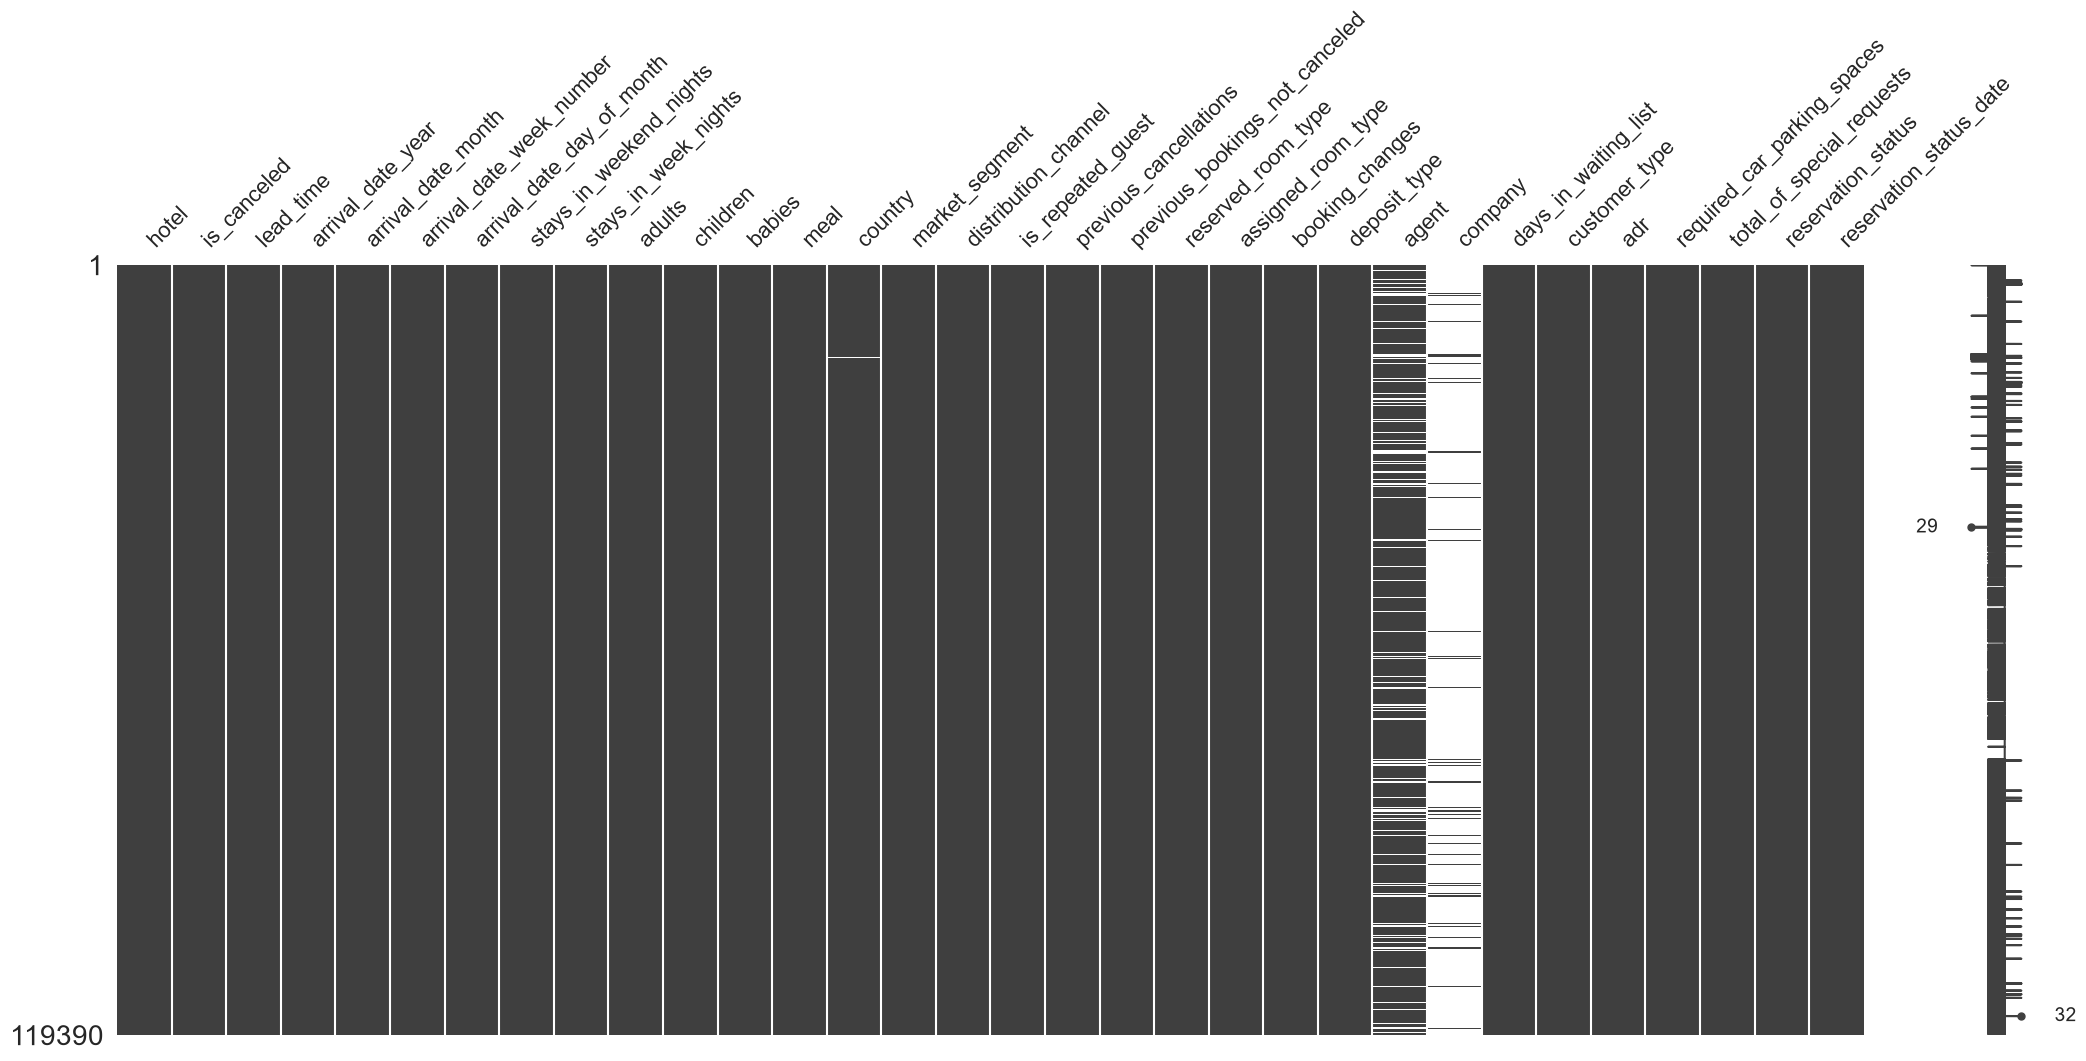

In [5]:
msno.matrix(df); plt.show()

Decision: `company` (94.3% missing) and `agent` (13.7% missing) are ID-like columns where NaN plausibly means "no travel agent/company involved" — treat missing as its own category, not impute. `country` (0.4%) genuinely missing, drop or bucket as "Unknown".

## 3. Duplicates

In [6]:
print("full-row dup:", df.duplicated().sum(), f"({df.duplicated().mean():.1%})")
print("dup excl. reservation_status/date:", df.drop(columns=["reservation_status", "reservation_status_date"]).duplicated().sum())

full-row dup: 31994 (26.8%)
dup excl. reservation_status/date: 32252


**No booking ID column exists in this dataset at all** — not even a surrogate key. 26.8% of rows are exact full-row duplicates. This is a documented quirk of the public release (Antonio et al. anonymized and stripped any PMS booking identifier), not a join/ETL bug on our side — cannot deduplicate with confidence, and cannot tell repeat real-world bookings from re-published rows.

## 4. Univariate Analysis

In [7]:
df[["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "children", "babies"]].describe()

,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights,adults,children,babies
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000
mean,104.011416,101.831122,2.500302,0.927599,1.856403,0.103890,0.007949
std,106.863097,50.535790,1.908286,0.998613,0.579261,0.398561,0.097436
min,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,69.290000,1.000000,0.000000,2.000000,0.000000,0.000000
50%,69.000000,94.575000,2.000000,1.000000,2.000000,0.000000,0.000000
75%,160.000000,126.000000,3.000000,2.000000,2.000000,0.000000,0.000000
max,737.000000,5400.000000,50.000000,19.000000,55.000000,10.000000,10.000000


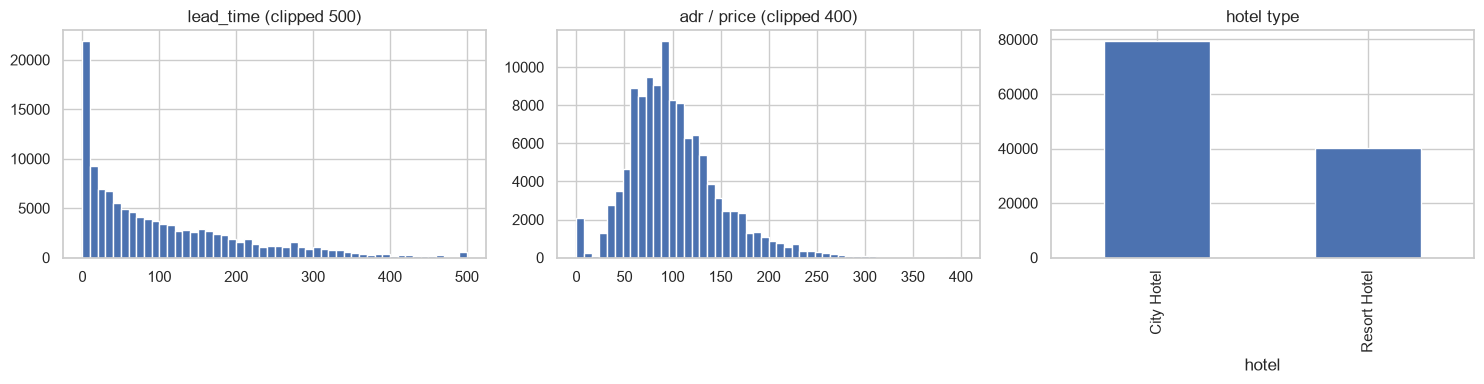

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["lead_time"].clip(0, 500).hist(bins=50, ax=ax[0]); ax[0].set_title("lead_time (clipped 500)")
df["adr"].clip(0, 400).hist(bins=50, ax=ax[1]); ax[1].set_title("adr / price (clipped 400)")
df["hotel"].value_counts().plot(kind="bar", ax=ax[2]); ax[2].set_title("hotel type")
plt.tight_layout(); plt.show()

In [9]:
df["market_segment"].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

## 5. Outliers

In [10]:
print("adr < 0:", (df["adr"] < 0).sum())
print("adr == 0:", (df["adr"] == 0).sum(), f"({(df['adr']==0).mean():.1%})")
print("adr > 1000:", (df["adr"] > 1000).sum(), "| max:", df["adr"].max())
zero_occupancy = (df["adults"] == 0) & (df["children"].fillna(0) == 0) & (df["babies"] == 0)
print("zero-occupancy bookings (adults=children=babies=0):", zero_occupancy.sum())

adr < 0: 1
adr == 0: 1959 (1.6%)
adr > 1000: 1 | max: 5400.0
zero-occupancy bookings (adults=children=babies=0): 180


Decision: 1 negative `adr` row and 1 extreme outlier (5,400) are data errors — clip or drop before using `adr` as a price feature. 180 zero-occupancy rows are invalid bookings — drop.

## 6. Target Variable

In [11]:
df["reservation_status"].value_counts(normalize=True).mul(100).round(1)

reservation_status
Check-Out    63.0
Canceled     36.0
No-Show       1.0
Name: proportion, dtype: float64

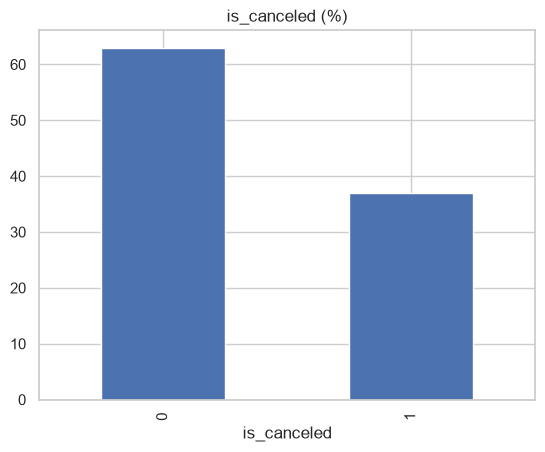

In [12]:
df["is_canceled"].value_counts(normalize=True).mul(100).round(1).plot(kind="bar", title="is_canceled (%)")
plt.show()

37.0% of bookings are canceled. If framing as room-type recommendation, canceled bookings are a weaker positive signal than completed stays (`reservation_status == "Check-Out"`) — same click-vs-book distinction as Expedia.

## 7. Bivariate / Correlation Analysis

In [13]:
pd.crosstab(df["hotel"], df["reserved_room_type"], normalize="index").round(3)

reserved_room_type,A,B,C,D,E,F,G,H,L,P
hotel,,,,,,,,,,
City Hotel,0.789,0.014,0.000,0.148,0.020,0.023,0.006,0.000,0.0,0.0
Resort Hotel,0.584,0.000,0.023,0.186,0.124,0.028,0.040,0.015,0.0,0.0


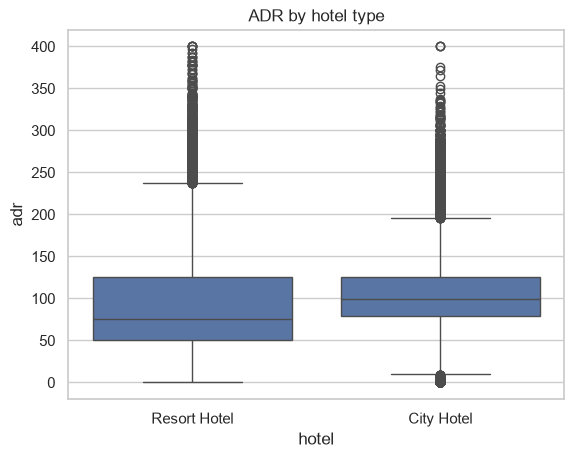

In [14]:
sns.boxplot(x=df["hotel"], y=df["adr"].clip(0, 400))
plt.title("ADR by hotel type"); plt.show()

In [15]:
print("reserved != assigned room type:", (df["reserved_room_type"] != df["assigned_room_type"]).mean())

reserved != assigned room type: 0.12494346260155792


## 8. Time-based Checks

arrival years: [np.int64(2015), np.int64(2016), np.int64(2017)]
reservation_status_date range: 2014-10-17 00:00:00 to 2017-09-14 00:00:00


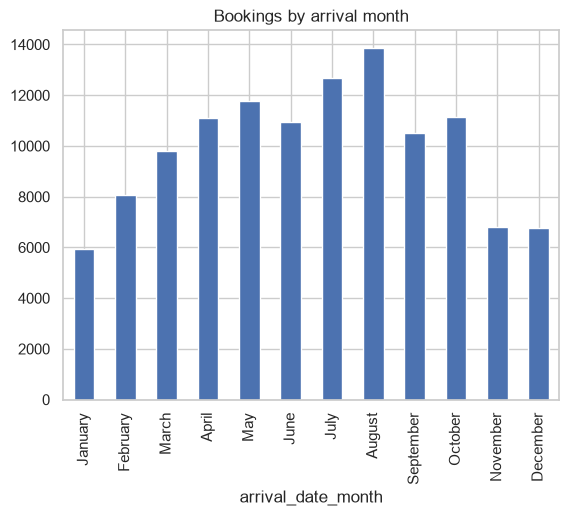

In [16]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
print("arrival years:", sorted(df["arrival_date_year"].unique()))
print("reservation_status_date range:", df["reservation_status_date"].min(), "to", df["reservation_status_date"].max())
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["arrival_date_month"].value_counts().reindex(month_order).plot(kind="bar", title="Bookings by arrival month")
plt.show()

Clear seasonality (peak Jul/Aug), 3-year span (2015-2017) — good for a seasonal-context task, but only at the aggregate level since there is no per-guest sequence.

## 9. Data Consistency

In [17]:
print("n unique country codes:", df["country"].nunique())
print(df["country"].value_counts(normalize=True).mul(100).round(1).head(5))
print()
print("agent nunique:", df["agent"].nunique(), "| company nunique:", df["company"].nunique())

n unique country codes: 177
country
PRT    40.9
GBR    10.2
FRA     8.8
ESP     7.2
DEU     6.1
Name: proportion, dtype: float64

agent nunique: 333 | company nunique: 352


48.6% of bookings are guests from Portugal (PRT) — the hotel's own country, expected for a domestic-heavy resort/city hotel, but a strong geographic skew to flag.

## 10. Feature Relationships for Recommendation Context

In [18]:
print("is_repeated_guest rate:", f"{df['is_repeated_guest'].mean():.2%}")
print("NOTE: there is no booking ID or guest ID column anywhere in this file.")
print("is_repeated_guest is only a boolean flag (already computed by the original authors from data we do not have) -- it cannot be used to reconstruct which rows belong to the same guest.")
print()
proxy = df.groupby("country")["reserved_room_type"].value_counts().unstack(fill_value=0)
print("proxy interaction matrix (country x room_type) shape:", proxy.shape)
sparsity = 1 - (proxy.values > 0).sum() / proxy.size
print(f"sparsity: {sparsity:.2%}")

is_repeated_guest rate: 3.19%
NOTE: there is no booking ID or guest ID column anywhere in this file.
is_repeated_guest is only a boolean flag (already computed by the original authors from data we do not have) -- it cannot be used to reconstruct which rows belong to the same guest.

proxy interaction matrix (country x room_type) shape: (177, 10)
sparsity: 63.05%


No real user/session actor exists in this dataset. The only usable "recommendation core" is a weak, aggregate proxy: **country x room_type** (177 countries x 10 room types) — not a personalized recommendation task, closer to population-level preference than next-best-item for an individual.

## 11. Summary

- Shape: 119,390 bookings, 32 columns. 2 hotels (City Hotel 66.4%, Resort Hotel 33.6%), Portugal, 2015-2017.
- **No booking ID or guest ID column exists at all** — this is the dataset's defining limitation. 26.8% full-row duplicates cannot be resolved (documented public-release quirk, not our ETL bug).
- `is_repeated_guest` is a pre-computed boolean (3.2% of rows) but gives no way to link which rows are the same guest.
- Missing: `company` 94.3% (mostly N/A = no company involved), `agent` 13.7%, `country` 0.4%.
- Data errors: 1 negative `adr`, 1 extreme `adr` outlier (5,400), 180 zero-occupancy bookings — all need cleanup.
- Rich trip context (arrival date, lead_time, party size, meal, market_segment, distribution_channel, deposit_type, special requests) and real target-like signal (`reservation_status`: Check-Out/Canceled/No-Show, 37.0% cancellation rate).
- Recommendation framing: only a weak proxy exists — `country` (guest origin) x `reserved_room_type` (10 categories), an aggregate population-preference matrix, not a personalized next-best-item task. No user history, no sequences, no cold-start structure to speak of (there is no actor to be cold on).
- Best used as: a context/cancellation-prediction reference or a coarse room-type popularity-by-origin check, not a core recommendation benchmark dataset.